# 판다스
### 1. 판다스 사용 준비

In [2]:
import pandas as pd
pd.__version__

'2.3.3'

### 2. 시리즈 객체의 생성과 수정 

In [5]:
numbers = [1, 2, 3, 4, 5]
list_sr = pd.Series(numbers)
print(list_sr)
type(list_sr)

0    1
1    2
2    3
3    4
4    5
dtype: int64


pandas.core.series.Series

In [6]:
print(list_sr.dtype, list_sr.shape, list_sr.size, list_sr.name)

int64 (5,) 5 None


In [7]:
dict_data = {'a' : 1, 'b' : 2, 'c' : 3, 'd' : 4, 'e' :5}
dict_sr = pd.Series(dict_data)
print(dict_sr)
print(dict_sr.dtype, dict_sr.shape, dict_sr.size, dict_sr.name)

a    1
b    2
c    3
d    4
e    5
dtype: int64
int64 (5,) 5 None


In [8]:
list_sr.name = 'mySeries'
list_sr

0    1
1    2
2    3
3    4
4    5
Name: mySeries, dtype: int64

In [9]:
list_sr.name

'mySeries'

In [11]:
import numpy as np
sr1 = pd.Series(numbers, dtype = np.float32)
sr1

0    1.0
1    2.0
2    3.0
3    4.0
4    5.0
dtype: float32

In [12]:
chars = 'a b c d e'.split()
sr3 = pd.Series(numbers, index = chars, name = 'mySeries')
sr3

a    1
b    2
c    3
d    4
e    5
Name: mySeries, dtype: int64

In [13]:
sr3.index, sr3.values

(Index(['a', 'b', 'c', 'd', 'e'], dtype='object'), array([1, 2, 3, 4, 5]))

In [14]:
list_sr.index

RangeIndex(start=0, stop=5, step=1)

### 3. 데이터프레임 객체 다루기
#### 3-1. 데이터프레임 객체의 생성과 속성 수정

In [17]:
numbers = [1, 2, 3, 4, 5]
pd1 = pd.DataFrame(numbers)
pd1

,0
0,1
1,2
2,3
3,4
4,5


In [19]:
pd2 = pd.DataFrame(numbers, columns = ['number'])
pd2

,number
0,1
1,2
2,3
3,4
4,5


In [20]:
score = [['정약용', 70, 80, 100],
         ['이순신', 100, 80, 70],
         ['이율곡', 90, 95, 90]]

score_df = pd.DataFrame(score)
score_df

,0,1,2,3
0,정약용,70,80,100
1,이순신,100,80,70
2,이율곡,90,95,90


In [21]:
score_df.columns = ['이름', '국어', '영어', '수학']
score_df

,이름,국어,영어,수학
0,정약용,70,80,100
1,이순신,100,80,70
2,이율곡,90,95,90


In [23]:
score_df2 = pd.DataFrame(score, columns = ['이름', '국어', '영어', '수학'])
score_df2

,이름,국어,영어,수학
0,정약용,70,80,100
1,이순신,100,80,70
2,이율곡,90,95,90


In [24]:
score_df.shape, score_df.index, score_df.columns

((3, 4),
 RangeIndex(start=0, stop=3, step=1),
 Index(['이름', '국어', '영어', '수학'], dtype='object'))

In [25]:
score_df.dtypes

이름    object
국어     int64
영어     int64
수학     int64
dtype: object

In [27]:
print(score_df.values)

[['정약용' 70 80 100]
 ['이순신' 100 80 70]
 ['이율곡' 90 95 90]]


#### 3-2. 데이터프레임의 열(칼럼) 추가

In [29]:
score_dict = {'이름' : ['정약용', '이순신', '이율곡', '홍길동'],
              '국어' : [70, 100, 90, 85],
              '영어' : [80, 80, 95, 100],
              '수학' : [100, 70, 90, 90]}
score_df = pd.DataFrame(score_dict)
score_df

,이름,국어,영어,수학
0,정약용,70,80,100
1,이순신,100,80,70
2,이율곡,90,95,90
3,홍길동,85,100,90


In [24]:
score_df['사회'] = [85, 88, 92, 96]
# score_df['사회'] = 100 이렇게 하면  사회점수에 그냥 100이 다들어감
score_df

,이름,국어,영어,수학,사회
0,정약용,70,80,100,85
1,이순신,100,80,70,88
2,이율곡,90,95,90,92
3,홍길동,85,100,90,96


In [25]:
# score_df['총점'] = score_df['국어'] + score_df['영어'] + score_df['수학'] + score_df['사회']
score_df['총점'] = score_df.국어 + score_df.영어 + score_df.수학 + score_df.사회
score_df['평균'] = score_df.총점 / 4
score_df

,이름,국어,영어,수학,사회,총점,평균
0,정약용,70,80,100,85,335,83.75
1,이순신,100,80,70,88,338,84.50
2,이율곡,90,95,90,92,367,91.75
3,홍길동,85,100,90,96,371,92.75


In [41]:
x = [0, 1, 2, 3, 4, 5]
y = [0, 2, 4, 6, 8, 10]
df = pd.DataFrame()
df['x'] = x
df['y'] = y
df['x * y'] = df.x * df.y
df


,x,y,x * y
0,0,0,0
1,1,2,2
2,2,4,8
3,3,6,18
4,4,8,32
5,5,10,50


#### 3-3. 데이터프레임의 행/열 삭제, 인덱스 초기화

In [9]:
score_dict = {'이름' : ['정약용', '이순신', '이율곡', '홍길동'],
              '국어' : [70, 100, 90, 85],
              '영어' : [80, 80, 95, 100],
              '수학' : [100, 70, 90, 90]}
score_df = pd.DataFrame(score_dict)
score_df

,이름,국어,영어,수학
0,정약용,70,80,100
1,이순신,100,80,70
2,이율곡,90,95,90
3,홍길동,85,100,90


In [10]:
score_df.drop(['이름'], axis = 1)

,국어,영어,수학
0,70,80,100
1,100,80,70
2,90,95,90
3,85,100,90


In [12]:
new_df = score_df.drop([0, 2], axis = 0) # 행을 없애는 거면 axis값이 0이 기본값이어서 안써도 됨
new_df

,이름,국어,영어,수학
1,이순신,100,80,70
3,홍길동,85,100,90


In [21]:
# new_df.reset_index() # 이전 index를 살리고 싶다면 이렇게
new_df.reset_index(drop = True, inplace = True)
new_df

,이름,국어,영어,수학
0,이순신,100,80,70
1,홍길동,85,100,90


#### 3-4. 데이터의 접근

In [26]:
score_df

,이름,국어,영어,수학,사회,총점,평균
0,정약용,70,80,100,85,335,83.75
1,이순신,100,80,70,88,338,84.50
2,이율곡,90,95,90,92,367,91.75
3,홍길동,85,100,90,96,371,92.75


##### 3-4-1. 직접 접근 방법

In [27]:
score_df['이름']

0    정약용
1    이순신
2    이율곡
3    홍길동
Name: 이름, dtype: object

In [28]:
score_df[['이름', '총점']]

,이름,총점
0,정약용,335
1,이순신,338
2,이율곡,367
3,홍길동,371


In [30]:
score_df[1] # KeyError

KeyError: 1

In [32]:
score_df[1:]

,이름,국어,영어,수학,사회,총점,평균
1,이순신,100,80,70,88,338,84.50
2,이율곡,90,95,90,92,367,91.75
3,홍길동,85,100,90,96,371,92.75


In [36]:
score_df[1:][['이름', '총점']]

,이름,총점
1,이순신,338
2,이율곡,367
3,홍길동,371


In [37]:
score_df.loc[1, ['이름', '총점']]

이름    이순신
총점    338
Name: 1, dtype: object

##### 3-4-2. Boolean Indexing

In [67]:
score_df[score_df.수학 > 80]

,이름,국어,영어,수학,사회,총점,평균
0,정약용,70,80,100,85,335,83.75
2,이율곡,90,95,90,92,367,91.75
3,홍길동,85,100,90,96,371,92.75


In [40]:
score_df[(score_df.국어 > 80) & (score_df.영어 < 90)]

,이름,국어,영어,수학,사회,총점,평균
1,이순신,100,80,70,88,338,84.5


In [42]:
score_df[score_df.이름.isin(['정약용', '이순신'])]

,이름,국어,영어,수학,사회,총점,평균
0,정약용,70,80,100,85,335,83.75
1,이순신,100,80,70,88,338,84.50


#### 3-4-3. 인덱서를 이용한 접근(loc, iloc)

In [44]:
score_df

,이름,국어,영어,수학,사회,총점,평균
0,정약용,70,80,100,85,335,83.75
1,이순신,100,80,70,88,338,84.50
2,이율곡,90,95,90,92,367,91.75
3,홍길동,85,100,90,96,371,92.75


In [47]:
score_df.loc[0:2, '국어':'수학']

,국어,영어,수학
0,70,80,100
1,100,80,70
2,90,95,90


In [50]:
score_df.iloc[0:2, 1:3] # iloc는 파이썬 인덱스와 같아짐

,국어,영어
0,70,80
1,100,80


#### 3-4-4. 파일 로딩, 데이터 확인

In [53]:
filename = './data/sample_data.csv'
sample_df = pd.read_csv(filename)
sample_df.head(3)

,Name,Age,Gender,City
0,Alice,24.0,F,New York
1,Bob,NaN,M,Los Angeles
2,Charlie,22.0,M,NaN


In [55]:
sample_df.tail(3)

,Name,Age,Gender,City
4,Edward,NaN,M,Houston
5,Alice,24.0,F,New York
6,Susan,32.0,F,Houston


In [57]:
len(sample_df), sample_df.shape

(7, (7, 4))

In [58]:
sample_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Name    7 non-null      object 
 1   Age     5 non-null      float64
 2   Gender  7 non-null      object 
 3   City    6 non-null      object 
dtypes: float64(1), object(3)
memory usage: 352.0+ bytes


In [59]:
sample_df.describe()

,Age
count,5.000000
mean,26.200000
std,4.147288
min,22.000000
25%,24.000000
50%,24.000000
75%,29.000000
max,32.000000


In [65]:
sample_df['Gender'].value_counts()

Gender
M    4
F    3
Name: count, dtype: int64

### 3-6. 데이터프레임 시각화

In [2]:
import pandas as pd
df = pd.DataFrame({'sales': [3, 5, 2, 8, 10],
                   'revenue': [4, 6, 4, 9, 12]})
df

,sales,revenue
0,3,4
1,5,6
2,2,4
3,8,9
4,10,12


<Axes: xlabel='sales', ylabel='revenue'>

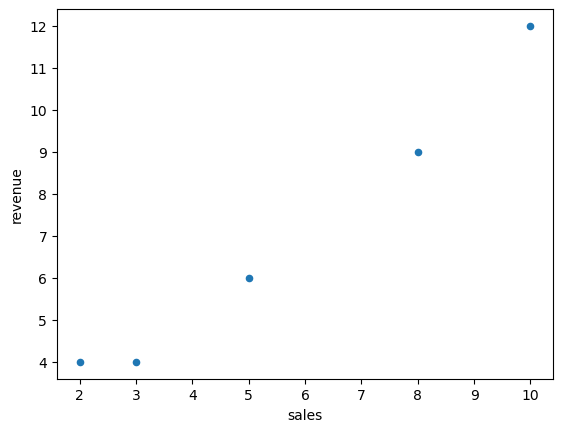

In [ ]:
df.plot(kind='scatter', x='sales', y='revenue') # bar 세로, barh 가로, hist 누적, scatter(x, y 지정해야함) 분포도 확인

### 3-7. 결측치, 중복치 처리

In [3]:
sample_df = pd.read_csv('./data/sample_data.csv')
sample_df.head()

,Name,Age,Gender,City
0,Alice,24.0,F,New York
1,Bob,NaN,M,Los Angeles
2,Charlie,22.0,M,NaN
3,David,29.0,M,Chicago
4,Edward,NaN,M,Houston


In [14]:
sample_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Name    7 non-null      object 
 1   Age     5 non-null      float64
 2   Gender  7 non-null      object 
 3   City    6 non-null      object 
dtypes: float64(1), object(3)
memory usage: 352.0+ bytes


In [16]:
sample_df.isnull().sum()

Name      0
Age       2
Gender    0
City      1
dtype: int64

In [17]:
sample_df.isnull().any(axis=1)

0    False
1     True
2     True
3    False
4     True
5    False
6    False
dtype: bool

In [18]:
sample_df[sample_df.isnull().any(axis=1)]

,Name,Age,Gender,City
1,Bob,NaN,M,Los Angeles
2,Charlie,22.0,M,NaN
4,Edward,NaN,M,Houston


In [ ]:
sample_df.dropna(subset=['Age'], inplace=True) # inplacr True면 실제 데이터프레임 가격이 바꿈
sample_df

,Name,Age,Gender,City
0,Alice,24.0,F,New York
2,Charlie,22.0,M,NaN
3,David,29.0,M,Chicago
5,Alice,24.0,F,New York
6,Susan,32.0,F,Houston


In [ ]:
sample_df.duplicated()

0    False
1    False
2    False
3    False
4    False
5     True
6    False
dtype: bool

In [5]:
sample_df.duplicated().sum()

np.int64(1)

In [ ]:
sample_df[sample_df.duplicated(keep=False)]

,Name,Age,Gender,City
0,Alice,24.0,F,New York
5,Alice,24.0,F,New York


In [ ]:
sample_df.drop_duplicates()

,Name,Age,Gender,City
0,Alice,24.0,F,New York
1,Bob,NaN,M,Los Angeles
2,Charlie,22.0,M,NaN
3,David,29.0,M,Chicago
4,Edward,NaN,M,Houston
6,Susan,32.0,F,Houston


In [10]:
sample_df

,Name,Age,Gender,City
0,Alice,24.0,F,New York
1,Bob,NaN,M,Los Angeles
2,Charlie,22.0,M,NaN
3,David,29.0,M,Chicago
4,Edward,NaN,M,Houston
5,Alice,24.0,F,New York
6,Susan,32.0,F,Houston


In [9]:
sample_df.drop_duplicates(subset=['City'])

,Name,Age,Gender,City
0,Alice,24.0,F,New York
1,Bob,NaN,M,Los Angeles
2,Charlie,22.0,M,NaN
3,David,29.0,M,Chicago
4,Edward,NaN,M,Houston
